In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from utils.load_datasets import QM9Loader
from ase.io import write, read
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.spatial.distance import pdist

from utils.load_datasets import QM9Loader
from scripts.features import get_features_xyz, get_raw_xyz_features

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
qm9_loader = QM9Loader()
frames = qm9_loader.get_stress_test_data()

In [6]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 200 total frames.
[[ 2.23479131 -1.23890526 -0.15114536]
 [ 1.26223544 -0.81651978 -0.08916716]
 [ 1.40974743  0.79468064  0.09235649]
 [ 0.06662947  1.38542971  0.09025475]
 [-1.16100661  0.72018647 -0.05868188]
 [-1.20831189 -0.79789938  0.02779222]
 [ 0.01680941 -1.46143518 -0.03295169]
 [ 2.126203    1.32916262  0.16499038]
 [-0.02946341  2.49607651  0.27047955]
 [-2.2232373   0.96544116  0.21297781]
 [-2.07552691 -1.37314021 -0.12346329]
 [ 0.0199374  -2.48754814 -0.08901461]]
qm9_894
O=c1cccc[nH]1


In [ ]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_894:
Max displacement: 4.8149 Å
Min displacement: 1.3578 Å
Average displacement: 2.7616 Å (Target was ~0.2)


In [ ]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.0621 Å
Standard Deviation of bond length: 0.1408 Å


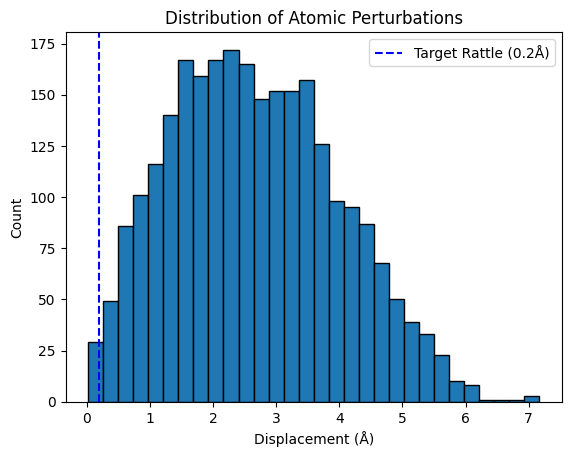

In [ ]:
all_displacements = []

for m in range(0, 200, 20):
    ref_pos = frames[m].get_positions()
    for p in range(1, 20):
        pert_pos = frames[m + p].get_positions()
        diff = np.linalg.norm(pert_pos - ref_pos, axis=1)
        all_displacements.extend(diff)

plt.hist(all_displacements, bins=30, edgecolor='black')
plt.axvline(0.2, color='blue', linestyle='--', label='Target Rattle (0.2Å)')
plt.title("Distribution of Atomic Perturbations")
plt.xlabel("Displacement (Å)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Clustering

In [10]:
import polars as pl

def make_clustering(frames, processed=False):
    # --- 1. Generate Features ---
    print("Generating geometric features...")
    if processed:
        X = get_features_xyz(frames)
    else:
        X = get_raw_xyz_features(frames)
        
    print(f"Feature matrix shape: {X.shape}")

    # --- 2. Clustering (K-Means) ---
    unique_mol_ids = list(set([f.info['mol_id'] for f in frames]))
    n_clusters = len(unique_mol_ids)

    print(f"Clustering into {n_clusters} clusters (based on unique mol_ids found)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # --- 3. Evaluation ---
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info['smiles'] for f in frames]

    # Calculate Score
    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"Clustering Performance (Adjusted Rand Index): {ari_score:.4f}")

    # --- 4. Cluster Composition Table ---
    # We create a dataframe to easily group and see what went where
    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    # Summary: For each cluster, show which molecules it contains and how many
    # If ARI is 1.0, each cluster should only contain 1 unique mol_id
    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    print("\nCluster Composition Summary:")
    print(summary_table)

    # --- 5. Visualization (PCA) ---
    print("\nRunning PCA for visualization...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6)
    
    title_prefix = "Processed (Invariant)" if processed else "Flattened (Raw)"
    plt.title(f"{title_prefix} XYZ Coordinates\nClustering of Perturbed Geometries (ARI={ari_score:.2f})")
    
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(*scatter.legend_elements(), title="Cluster ID")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return summary_table

Generating geometric features...
Feature matrix shape: (200, 171)
Clustering into 10 clusters (based on unique mol_ids found)...
Clustering Performance (Adjusted Rand Index): 1.0000

Cluster Composition Summary:
shape: (10, 5)
┌─────────┬─────────────┬────────────────────┬───────────────────────┬───────────────┐
│ cluster ┆ unique_mols ┆ mol_ids_in_cluster ┆ representative_smiles ┆ total_samples │
│ ---     ┆ ---         ┆ ---                ┆ ---                   ┆ ---           │
│ i32     ┆ u32         ┆ list[str]          ┆ str                   ┆ u32           │
╞═════════╪═════════════╪════════════════════╪═══════════════════════╪═══════════════╡
│ 0       ┆ 1           ┆ ["qm9_355"]        ┆ COC(=O)CN             ┆ 20            │
│ 1       ┆ 1           ┆ ["qm9_1316"]       ┆ CC1(C)OCCO1           ┆ 20            │
│ 2       ┆ 1           ┆ ["qm9_1009"]       ┆ O=Cn1ccnc1            ┆ 20            │
│ 3       ┆ 1           ┆ ["qm9_563"]        ┆ C#CC[NH+]1CC1         ┆ 20    

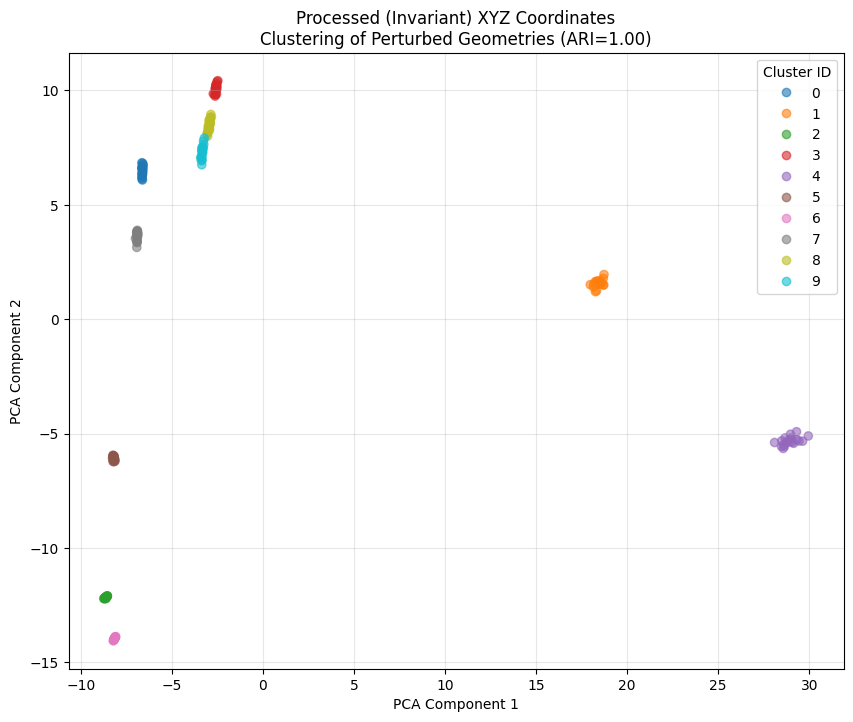

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_355""]","""COC(=O)CN""",20
1,1,"[""qm9_1316""]","""CC1(C)OCCO1""",20
2,1,"[""qm9_1009""]","""O=Cn1ccnc1""",20
3,1,"[""qm9_563""]","""C#CC[NH+]1CC1""",20
4,1,"[""qm9_1066""]","""CC(C)(O)CCO""",20
5,1,"[""qm9_894""]","""O=c1cccc[nH]1""",20
6,1,"[""qm9_767""]","""Oc1cn[nH]c1""",20
7,1,"[""qm9_1131""]","""C#C[C@](C)(O)C=O""",20
8,1,"[""qm9_178""]","""ONC1CNC1""",20


In [11]:
make_clustering(frames, processed=True)

Generating geometric features...
Feature matrix shape: (200, 57)
Clustering into 10 clusters (based on unique mol_ids found)...
Clustering Performance (Adjusted Rand Index): 1.0000
Running PCA for visualization...


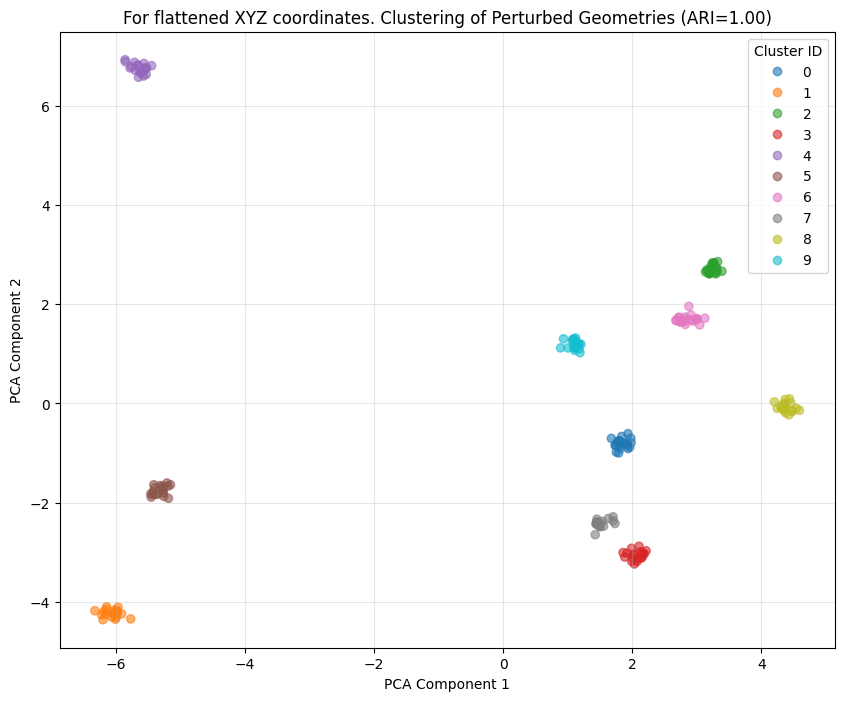

In [9]:
make_clustering(frames, processed=False)